# **4장 : 분류**
# **4.1 분류의 개요**
# **4.2 결정 트리**

# 지도학습
명시적인 정답이 있는 데이터가 주어진 상태에서 학습하는 머신러닝 방식  
Classification : 학습한 모델에 새로운 값이 주어졌을 때 그 결과를 예측  
분류는 다음과 같은 머신러닝 알고리즘으로 구현할 수 있음.  
1. 나이브 베이즈
2. 로지스틱 회귀
3. 결정 트리
4. 서포트 벡터 머신
5. 최소 근접 알고리즘
6. 신경망  
7. 앙상블 : 머신러닝 알고리즘 결합  
7-(1) Bagging  
7-(2) Boosting
  
우리는 여기에서 앙상블(Ensemble)을 집중적으로 볼거임  
Bagging: 데이터의 랜덤 샘플링(중복 허용)을 통해 여러 모델을 학습시킨 뒤, 그 결과를 평균 또는 다수결로 결정함.  
대표 알고리즘: 랜덤 포레스트(Random Forest)  
Boosting: 이전 모델이 틀린 예측에 가중치를 부여하여, 다음 모델이 그 오류를 보완하도록 학습을 진행함.  
대표 알고리즘: Gradient Boosting, XGBoost  
이런 앙상블을 학습하는데 결정 트리가 좋음  

# 결정 트리
데이터에 있는 규칙을 학습을 통해 자동으로 찾아내 트리 기반의 분류 규칙을 만드는 것.  
루트 노드: 전체 데이터를 가장 처음 나누는 기준  
규칙 노드: 조건(예: x ≤ 3.5)에 따라 데이터를 계속 나누는 단계  
리프 노드: 최종 예측값을 담고 있는 노드  
**규칙 노드가 많아질수록 불류를 결정하는 방식이 복잡해지고, 이는 과적합으로 이어짐**  
그래서 규칙 노드를 가장 적게 하고, 최대한 많은 데이터 세트가 해당 분류에 속할 수 있도록 규칙을 정해야 함.  

정보 노드: 정보 균일도가 높은 데이터 세트를 먼저 선택할 수 있도록 규칠 조건을 만듦  
정보의 균일도를 측정하는 대표적인 방법 : 엔트로피를 이용한 정보 이득 지수 / 지니 계수  
서로 다른 값이 섞여 있으면 엔트로피가 높고, 같은 값이 섞여 있으면 엔트로피가 낮음.  
정보 이득 지수 = 1-엔트로피 -> 정보 이득 지수가 높은 속성을 기준으로 분할  
지니 계수 : 0이 가장 평등하고 1이 가장 불평등. 지니 계수가 낮은 속성을 기준으로 분할  
DecisionTreeClassifier : 결정 트리 알고리즘을 사이킷런에서 구현. 지니 계수를 이용해 분할  

결정 트리 장점 : 쉽다. 직관적이다. 피처의 스케일링이나 정규화 등의 사전 가공 영향도가 크지 않다.  
단점 : 과적합으로 알고리즘 성능이 떨어진다. 이를 극복하기 위해 트리의 크기를 사전에 제한하는 튜닝이 필요하다.  

### DecisionTreeClassifier : 분류를 위한 클래스
### DecisionTreeRegressor : 회귀를 위한 클래스
from sklearn.tree import DecisionTreeClassifier  
clf = DecisionTreeClassifier(min_samples_split=10,min_samples_leaf=5,max_features = auto, max_depth=5,max_leaf_nodes = 20)
  
min_samples_split: 노드를 분할하기 위한 최소 샘플 수  
min_samples_leaf: 리프 노드가 되기 위한 최소 샘플 수(과적합 방지용으로 자주 사용됨)  
max_features: 최적의 분할을 위해 고려할 최대 피처 개수.  
max_depth: 트리의 최대 깊이  
max_leaf_nodes: 말단 노드의 최대 개수  

# Graphviz 패키지 : 그래프 기반의 dot파일로 기술된 다양한 이미지를 쉽게 시각화. 결정 트리 알고리즘 쉽게 이해하는데 사용.

In [1]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

dt_clf = DecisionTreeClassifier(random_state = 156)

iris_data = load_iris()
X_train,X_test,y_train,y_test = train_test_split(iris_data.data, iris_data.target, test_size = 0.2, random_state=11)

dt_clf.fit(X_train,y_train)

DecisionTreeClassifier(random_state=156)

In [2]:
from sklearn.tree import export_graphviz

# export_graphviz의 호출 결과로 out_file로 지정된 tree.dot 파일을 생성함
export_graphviz(dt_clf, out_file = "tree.dot", class_names = iris_data.target_names,\
                feature_names=iris_data.feature_names, impurity=True, filled=True)

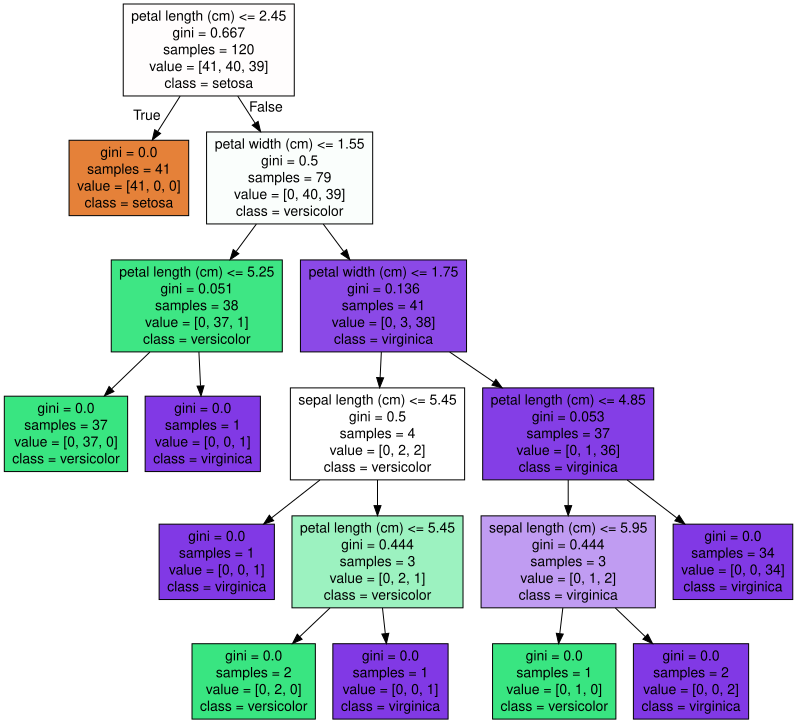

In [3]:
import graphviz

# 위에서 생성된 tree.dot 파일을 Graphviz가 읽어서 주피터 노트북상에서 시각화
with open("tree.dot") as f:
    dot_graph=f.read()

graphviz.Source(dot_graph)

feature_importances_: 모델이 예측을 수행할 때 각 특성이 정보 이득에 얼마나 기여했는지를 수치로 나타냄  
값 범위: 각 특성마다 0 이상 실수 값으로 주어지며, 전체 합은 1.0  
높을수록 중요한 특성이라는 의미  

Feature importances:
[0.025 0.    0.555 0.42 ]
sepal length (cm) : 0.025
sepal width (cm) : 0.000
petal length (cm) : 0.555
petal width (cm) : 0.420


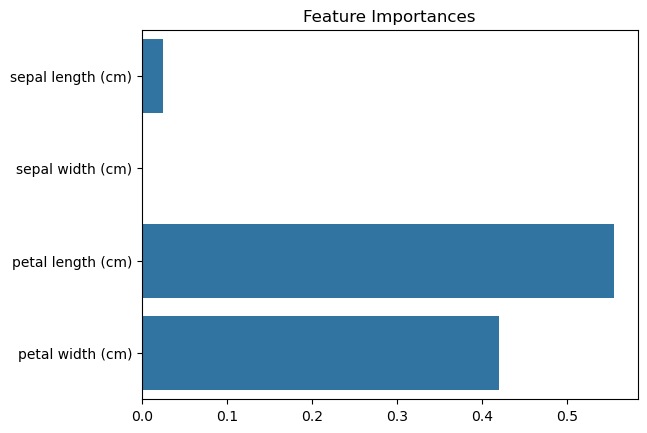

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Feature importances:\n{0}".format(np.round(dt_clf.feature_importances_,3)))

for name,value in zip(iris_data.feature_names,dt_clf.feature_importances_):
    print('{0} : {1:.3f}'.format(name,value))

sns.barplot(x=dt_clf.feature_importances_,y=iris_data.feature_names)
plt.title("Feature Importances")
plt.show()

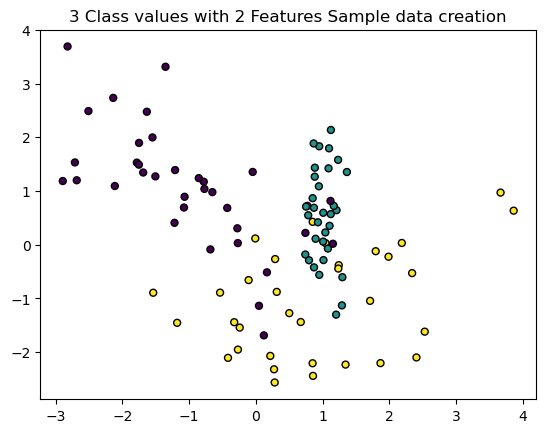

In [5]:
%matplotlib inline
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt 

plt.title("3 Class values with 2 Features Sample data creation")

X_features, y_labels = make_classification(
    n_features=2, # 특성(feature) 2개 (x, y 좌표처럼 시각화 가능)
    n_redundant=0, # 중복 정보가 있는 특성 없음
    n_informative=2, # 실제 분류에 의미 있는 특성 2개
    n_classes=3, # 클래스(레이블) 3개 → y값이 0, 1, 2
    n_clusters_per_class=1, # 클래스당 하나의 클러스터
    random_state=0
)

plt.scatter(X_features[:,0],X_features[:,1],marker='o',c=y_labels,s=25,edgecolor='k')
plt.show()

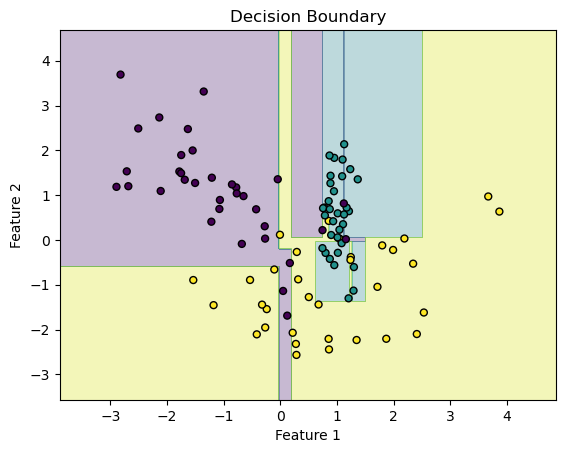

In [6]:
from sklearn.tree import DecisionTreeClassifier

def visualize_boundary(classifier, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.01),
        np.arange(y_min, y_max, 0.01)
    )
    
    # 각 좌표에 대한 예측
    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # 결정 경계 그리기
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=25, edgecolor='k')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Decision Boundary')
    plt.show()

# 특정한 트리 생성 제약 없는 결정 트리의 학습과 결정 경계 시각화
dt_clf = DecisionTreeClassifier(random_state=156).fit(X_features,y_labels)
visualize_boundary(dt_clf,X_features,y_labels)

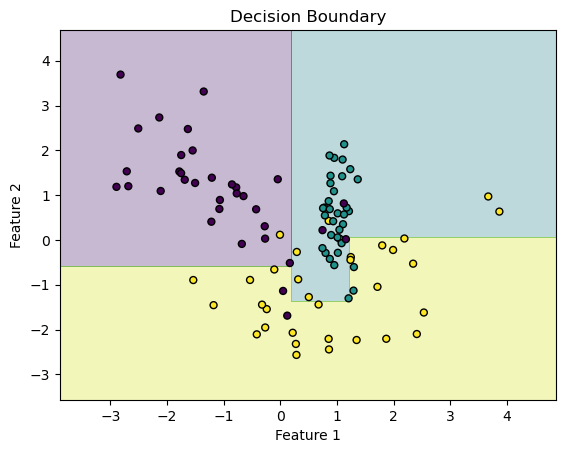

In [7]:
# min_samples_leaf=6으로 트리 생성 조건을 제약한 결정 경계 시각화
dt_clf = DecisionTreeClassifier(min_samples_leaf=6, random_state=156).fit(X_features,y_labels)
visualize_boundary(dt_clf,X_features,y_labels)

첫 번째 그림보다는 두 번째 그림이 훨씬 단순함.  
이상치에 크게 반응하지 않으면서 좀 더 일반화된 분류 규칙에 따라 분류됨.  
Overfitting 방지 -> 예측 성능은 min_samples_leaf=6으로 제약한 모델이 더 뛰어남

# 사용자 행동 인식 데이터 세트로 실습

분류 대상 활동 (6가지)  
1. WALKING  
2. WALKING_UPSTAIRS  
3. WALKING_DOWNSTAIRS  
4. SITTING  
5. STANDING  
6. LAYING  
→ 머신러닝 모델의 목표는 센서 데이터를 보고 이 6개 중 어떤 활동인지 분류하는 것.
  
### X_train.txt의 예시
[0.2777778 -0.0173832 -0.1111481 ... 0.1232132 -0.2341512 0.0125839]  
이 한 줄은 561개의 수치(feature)로 구성되어 있고, 이는 한 명의 피험자가 2.56초간 특정 활동을 한 시점의 센서 특징임  
각 값은 다음과 같은 센서 기반 통계적 특성을 의미함:  
tBodyAcc-mean()-X (몸통 가속도 평균, X축)  
tBodyAcc-std()-Y (몸통 가속도 표준편차, Y축)  
fBodyGyro-bandsEnergy()-X,8,24 (주파수 도메인 에너지 밴드 등)  
... 총 561개의 feature  
→ 즉, 이 한 줄 = 센서 데이터 시계열 → 통계적 요약 → 561차원 벡터  
 ### y_train.txt에서의 정답 라벨 예시
5   
이 경우는 STANDING을 의미한다.   

In [8]:
%matplotlib inline
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt 
import pandas as pd

# features.txt 파일에는 피처 이름 index와 피처명이 공백으로 분리되어 있음. 이를 DataFrame으로 로드.
feature_name_df = pd.read_csv('./human_activity/features.txt', sep='\s+',
                              header=None, names=['column_index', 'column_name'])

# 피처명 index를 제거하고, 피처명만 리스트 객체로 생성한 뒤 샘플로 10개만 추출
feature_name = feature_name_df.iloc[:,1].values.tolist()
print('전체 피처명에서 10개만 추출: ',feature_name[:10])

전체 피처명에서 10개만 추출:  ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X']


### 중복된 피처명 방지 : 원본 피처명에 _1 또는 _2 추가

In [9]:
feature_dup_df = feature_name_df.groupby('column_name').count()
print(feature_dup_df[feature_dup_df['column_index']>1].count())
feature_dup_df[feature_dup_df['column_index']>1].head()

column_index    42
dtype: int64


,column_index
column_name,
"fBodyAcc-bandsEnergy()-1,16",3
"fBodyAcc-bandsEnergy()-1,24",3
"fBodyAcc-bandsEnergy()-1,8",3
"fBodyAcc-bandsEnergy()-17,24",3
"fBodyAcc-bandsEnergy()-17,32",3


In [10]:
def get_new_feature_name_df(old_feature_name_df):
    feature_dup_df = pd.DataFrame(data=old_feature_name_df.groupby('column_name').cumcount(),
                                  columns=['dup_cnt'])
    feature_dup_df = feature_dup_df.reset_index()
    new_feature_name_df = pd.merge(old_feature_name_df.reset_index(), feature_dup_df, how = 'outer')
    new_feature_name_df['column_name']=new_feature_name_df[['column_name',
                                                            'dup_cnt']].apply(lambda x : x[0]+'_'+str(x[1]) if x[1]>0 else x[0], axis=1)
    new_feature_name_df = new_feature_name_df.drop(['index'], axis=1)
    return new_feature_name_df

In [11]:
import pandas as pd

def get_human_dataset():
    # 각 데이터 파일은 공백으로 분리되어 있으므로 read_csv에서 공백 문자를 sep으로 할당
    feature_name_df = pd.read_csv('./human_activity/features.txt', sep='\s+',
                              header=None, names=['column_index', 'column_name'])

    # 중복된 피처명을 수정하는 get_new_feature_name_df 이용, 신규 피처명 DataFrame 생성
    new_feature_name_df = get_new_feature_name_df(feature_name_df)

    # DataFrame에 피처명을 column으로 부여하기 위해 리스트 객체로 다시 변환
    feature_name = new_feature_name_df.iloc[:,1].values.tolist()

    # 학습 피처 데이터세트와 테스트 피처 데이터를 DataFrame으로 로딩. 칼럼명은 feature_name 적용
    X_train = pd.read_csv('./human_activity/train/X_train.txt',sep='\s+',names=feature_name)
    X_test = pd.read_csv('./human_activity/test/X_test.txt',sep='\s+',names=feature_name)

    # 학습 레이블과 테스트 레이블 데이터를 DataFrame으로 로딩하고 칼럼명은 action으로 부여
    y_train = pd.read_csv('./human_activity/train/y_train.txt',sep='\s+',names=['action'])
    y_test = pd.read_csv('./human_activity/test/y_test.txt',sep='\s+',names=['action'])

    return X_train,X_test,y_train,y_test

X_train,X_test,y_train,y_test = get_human_dataset()

In [12]:
print('## 학습 피처 데이터셋 info()')
print(X_train.info())

## 학습 피처 데이터셋 info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 561 entries, tBodyAcc-mean()-X to angle(Z,gravityMean)
dtypes: float64(561)
memory usage: 31.5 MB
None


In [13]:
print(y_train['action'].value_counts())

action
6    1407
5    1374
4    1286
1    1226
2    1073
3     986
Name: count, dtype: int64


## 동작 예측 분류 수행

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_clf = DecisionTreeClassifier(random_state = 156)
dt_clf.fit(X_train, y_train)
pred = dt_clf.predict(X_test)
accuracy = accuracy_score(y_test,pred)
print('결정 트리 예측 정확도: {0:.4f}'.format(accuracy))

print('DecisionTreeClassifier 기본 하이퍼 파라미터:\n', dt_clf.get_params())

결정 트리 예측 정확도: 0.8548
DecisionTreeClassifier 기본 하이퍼 파라미터:
 {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 156, 'splitter': 'best'}


## 트리의 깊이가 예측 정확도에 영향을 주는가?
## GridSearchCV : 최적 트리의 깊이, min_samples_split 찾기

In [15]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth' : [6,8,10,12,16,20,24],
    'min_samples_split':[16]
}

grid_cv = GridSearchCV(dt_clf, param_grid = params, scoring='accuracy', cv=5, verbose=1)
grid_cv.fit(X_train,y_train)
print('GridSearchCV 최고 평균 정확도 수치: {0:.4f}'.format(grid_cv.best_score_))
print('GridSearchCV 최적 하이퍼 파라미터:', grid_cv.best_params_)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
GridSearchCV 최고 평균 정확도 수치: 0.8549
GridSearchCV 최적 하이퍼 파라미터: {'max_depth': 8, 'min_samples_split': 16}


In [16]:
# GridSearchCV 객체의 cv_results_ 속성을 DataFrame으로 생성
cv_results_df = pd.DataFrame(grid_cv.cv_results_)

# max_depth 파라미터 값과 그때의 테스트 세트, 학습 데이터 세트의 정확도 수치 추출
cv_results_df[['param_max_depth','mean_test_score']]

,param_max_depth,mean_test_score
0,6,0.847662
1,8,0.854879
2,10,0.852705
3,12,0.845768
4,16,0.847127
5,20,0.848624
6,24,0.848624


In [17]:
max_depths = [6,8,10,12,16,20,24]

# max_depth 값을 변화시키면서 그때마다 학습과 테스트 세트에서의 예측 성능 측정
for depth in max_depths:
    dt_clf = DecisionTreeClassifier(max_depth=depth, min_samples_split = 16, random_state = 156)
    dt_clf.fit(X_train, y_train)
    pred = dt_clf.predict(X_test)
    accuracy = accuracy_score(y_test, pred)
    print('max_depth = {0} 정확도: {1:.4f}'.format(depth,accuracy))

max_depth = 6 정확도: 0.8551
max_depth = 8 정확도: 0.8717
max_depth = 10 정확도: 0.8599
max_depth = 12 정확도: 0.8571
max_depth = 16 정확도: 0.8599
max_depth = 20 정확도: 0.8565
max_depth = 24 정확도: 0.8565


max_depth가 8일 경우가 정확도가 제일 높고 그다음부터는 떨어짐  
결정 트리는 깊이가 깊어질수록 과적합의 영향력이 커지므로 파라미터를 이용해 깊이를 제어할 수 있어야함

## max_depth와 min_samples_split 같이 변경하면서 정확도 성능 튜닝

In [18]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth' : [8,12,16,20],
    'min_samples_split':[16,24]
}

grid_cv = GridSearchCV(dt_clf, param_grid = params, scoring='accuracy', cv=5, verbose=1)
grid_cv.fit(X_train,y_train)
print('GridSearchCV 최고 평균 정확도 수치: {0:.4f}'.format(grid_cv.best_score_))
print('GridSearchCV 최적 하이퍼 파라미터:', grid_cv.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
GridSearchCV 최고 평균 정확도 수치: 0.8549
GridSearchCV 최적 하이퍼 파라미터: {'max_depth': 8, 'min_samples_split': 16}


## grid_cv의 속성인 best_estimator_: 
## 최적 하이퍼 파라미터인 max_depth = 8, min_samples_split = 16으로 학습 완료
## 테스트 데이터 세트에 대한 예측 수행

In [20]:
best_df_clf = grid_cv.best_estimator_
pred1 = best_df_clf.predict(X_test)
accuracy = accuracy_score(y_test,pred1)
print('결정 트리 예측 정확도: {0:.4f}'.format(accuracy))

결정 트리 예측 정확도: 0.8717


## 결정 트리에서 각 피처의 중요도

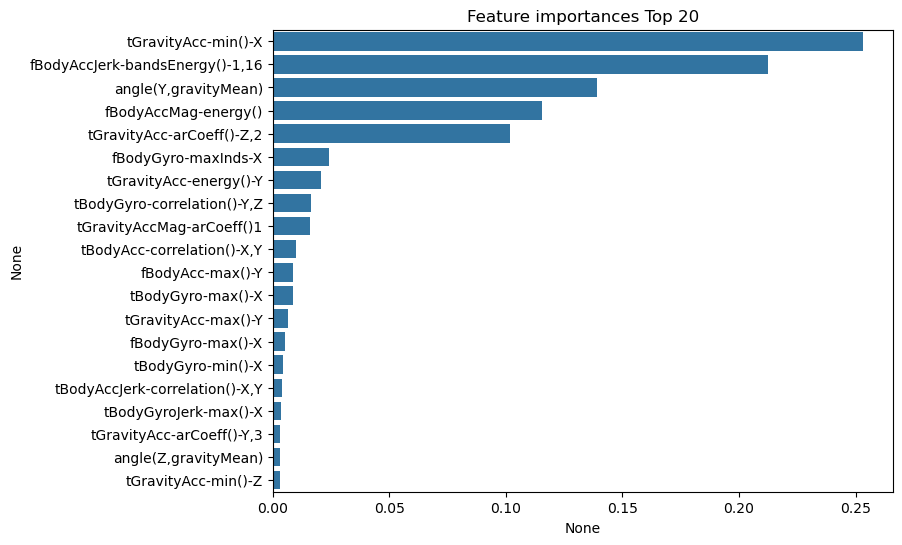

In [29]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

ftr_importances_values = best_df_clf.feature_importances_

# Top 중요도로 정렬을 쉽게 하고, Seaborn의 막대그래프로 쉽게 표현하기 위해 Series 변환
ftr_importances = pd.Series(ftr_importances_values, index = X_train.columns)

# 중요도값 순으로 Series를 정렬
ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]
plt.figure(figsize=(8,6))
plt.title('Feature importances Top 20')
sns.barplot(x=ftr_top20, y=ftr_top20.index)
plt.show()